### Demand Product Forecasting

In [61]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
# Download the dataset

df = pd.read_csv('data/stores/train.csv', sep=',', encoding='utf-8')

df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


### Cleaning Dataset

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [64]:
df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [65]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df['store_nbr'] = df['store_nbr'].astype('category')

In [66]:
print(df[df['date'] == '2016-12-25'])

Empty DataFrame
Columns: [id, date, store_nbr, family, sales, onpromotion]
Index: []


In [67]:
# Define the minimum and maximum dates in the dataset
data_min = df['date'].min()
data_max = df['date'].max()

# Create a complete calendar of dates from the minimum to the maximum date
calendario_completo = pd.date_range(start=data_min, end=data_max)

# Extract unique store numbers and product families from the dataset
lojas = df['store_nbr'].unique()
familias = df['family'].unique()

# Create a skeleton DataFrame with all combinations of dates, stores, and families
esqueleto = pd.MultiIndex.from_product(
    [calendario_completo, lojas, familias],
    names=['date', 'store_nbr', 'family']
).to_frame(index=False)

# Merge the skeleton DataFrame with the original dataset to fill in the sales data. 
# Days that exist in 'df' will be filled, while December 25th will have NaN values.
df_continuo = pd.merge(esqueleto, df, on=['date', 'store_nbr', 'family'], how='left')

# Verify NaN values for December 25th
print(df_continuo[df_continuo['date'] == '2016-12-25'])

              date store_nbr                      family  id  sales  \
2591028 2016-12-25         1                  AUTOMOTIVE NaN    NaN   
2591029 2016-12-25         1                   BABY CARE NaN    NaN   
2591030 2016-12-25         1                      BEAUTY NaN    NaN   
2591031 2016-12-25         1                   BEVERAGES NaN    NaN   
2591032 2016-12-25         1                       BOOKS NaN    NaN   
...            ...       ...                         ...  ..    ...   
2592805 2016-12-25         9                     POULTRY NaN    NaN   
2592806 2016-12-25         9              PREPARED FOODS NaN    NaN   
2592807 2016-12-25         9                     PRODUCE NaN    NaN   
2592808 2016-12-25         9  SCHOOL AND OFFICE SUPPLIES NaN    NaN   
2592809 2016-12-25         9                     SEAFOOD NaN    NaN   

         onpromotion  
2591028          NaN  
2591029          NaN  
2591030          NaN  
2591031          NaN  
2591032          NaN  
...      

In [68]:
# Substituir os NaNs (gerados pelos dias em que as lojas fecharam) por zero
df_continuo['sales'] = df_continuo['sales'].fillna(0)
df_continuo['onpromotion'] = df_continuo['onpromotion'].fillna(0)

# drop the 'id' column if it exists
df_continuo = df_continuo.drop(columns=['id'], errors='ignore')

In [69]:
# verify if NaNs were replaced
print(df_continuo[df_continuo['date'] == '2016-12-25'])

              date store_nbr                      family  sales  onpromotion
2591028 2016-12-25         1                  AUTOMOTIVE    0.0          0.0
2591029 2016-12-25         1                   BABY CARE    0.0          0.0
2591030 2016-12-25         1                      BEAUTY    0.0          0.0
2591031 2016-12-25         1                   BEVERAGES    0.0          0.0
2591032 2016-12-25         1                       BOOKS    0.0          0.0
...            ...       ...                         ...    ...          ...
2592805 2016-12-25         9                     POULTRY    0.0          0.0
2592806 2016-12-25         9              PREPARED FOODS    0.0          0.0
2592807 2016-12-25         9                     PRODUCE    0.0          0.0
2592808 2016-12-25         9  SCHOOL AND OFFICE SUPPLIES    0.0          0.0
2592809 2016-12-25         9                     SEAFOOD    0.0          0.0

[1782 rows x 5 columns]


In [70]:
df_continuo.head()

,date,store_nbr,family,sales,onpromotion
0,2013-01-01,1,AUTOMOTIVE,0.0,0.0
1,2013-01-01,1,BABY CARE,0.0,0.0
2,2013-01-01,1,BEAUTY,0.0,0.0
3,2013-01-01,1,BEVERAGES,0.0,0.0
4,2013-01-01,1,BOOKS,0.0,0.0


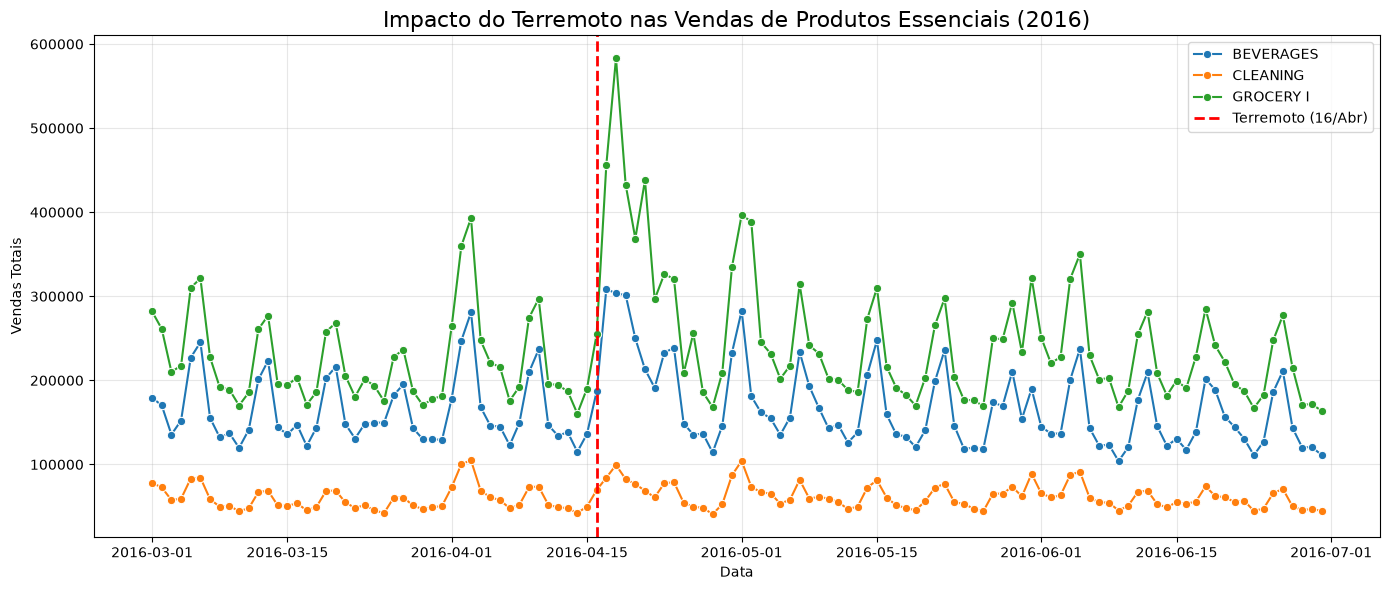

In [81]:
# Analysis of the impact of the earthquake on sales of essential products

df_zoom = df_continuo[
    (df_continuo['date'] >= '2016-03-01') & 
    (df_continuo['date'] <= '2016-06-30')
]

# Filter the families of interest (essential products)
familias_alvo = ['GROCERY I', 'CLEANING', 'BEVERAGES']
df_alvo = df_zoom[df_zoom['family'].isin(familias_alvo)]

# Aggregate sales by date and family
vendas_diarias = df_alvo.groupby(['date', 'family'])['sales'].sum().reset_index()

# Create a line plot to visualize the impact of the earthquake on sales
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=vendas_diarias, 
    x='date', 
    y='sales', 
    hue='family', 
    marker='o' 
)

# Add a vertical line to indicate the date of the earthquake
plt.axvline(
    pd.to_datetime('2016-04-16'), 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label='Terremoto (16/Abr)'
)

plt.title('Impacto do Terremoto nas Vendas de Produtos Essenciais (2016)', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Vendas Totais')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [82]:
# Create a flag to indicate the period of the earthquake and its impact on essential product sales
inicio_terremoto = '2016-04-16'
fim_impacto = '2016-05-16'

familias_essenciais = ['GROCERY I', 'BEVERAGES', 'CLEANING', 'WATER'] 
df_continuo['flag_doacao_terremoto'] = np.where(
    (df_continuo['date'].between(inicio_terremoto, fim_impacto)) & 
    (df_continuo['family'].isin(familias_essenciais)), 
    1, 
    0
)

df_continuo.head()

,date,store_nbr,family,sales,onpromotion,flag_doacao_terremoto
0,2013-01-01,1,AUTOMOTIVE,0.0,0.0,0
1,2013-01-01,1,BABY CARE,0.0,0.0,0
2,2013-01-01,1,BEAUTY,0.0,0.0,0
3,2013-01-01,1,BEVERAGES,0.0,0.0,0
4,2013-01-01,1,BOOKS,0.0,0.0,0
